In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [2]:
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# set a clean theme for plots
sns.set_theme(style="whitegrid")

# unzip
zip_file_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall("ipl_data")

# check extracted files
print("Extracted files:", os.listdir("ipl_data"))

# detect correct files automatically
files = os.listdir("ipl_data")
delivery_file = [f for f in files if "deliveries" in f.lower()][0]
match_file = [f for f in files if "matches" in f.lower()][0]

print("Using delivery file:", delivery_file)
print("Using match file:", match_file)

# load data
deliveries = pd.read_csv(f"ipl_data/{delivery_file}")
matches = pd.read_csv(f"ipl_data/{match_file}")

print("Deliveries shape:", deliveries.shape)
print("Matches shape:", matches.shape)

Extracted files: ['IPL_ball_by_ball_updated.csv', 'deliveries_updated_mens_ipl.csv', 'matches_updated_mens_ipl.csv', 'matches_updated_ipl_upto_2025.csv', 'deliveries_updated_ipl_upto_2025.csv']
Using delivery file: deliveries_updated_mens_ipl.csv
Using match file: matches_updated_mens_ipl.csv
Deliveries shape: (243817, 20)
Matches shape: (1024, 28)


In [3]:
print(deliveries.columns.tolist())
print(matches.columns.tolist())

['matchId', 'inning', 'over_ball', 'over', 'ball', 'batting_team', 'bowling_team', 'batsman', 'non_striker', 'bowler', 'batsman_runs', 'extras', 'isWide', 'isNoBall', 'Byes', 'LegByes', 'Penalty', 'dismissal_kind', 'player_dismissed', 'date']
['venue', 'umpire2', 'winner_runs', 'date', 'method', 'reserve_umpire', 'winner', 'city', 'balls_per_over', 'outcome', 'match_number', 'match_referee', 'team1', 'eliminator', 'date1', 'gender', 'team2', 'winner_wickets', 'toss_winner', 'toss_decision', 'date2', 'tv_umpire', 'season', 'umpire1', 'event', 'neutralvenue', 'player_of_match', 'matchId']


**Understand Structure of Data**

In [4]:
# display first 5 rows of deliveries dataset to understand structure
deliveries.head()

# display first 5 rows of matches dataset to understand structure
matches.head()

,venue,umpire2,winner_runs,date,method,reserve_umpire,winner,city,balls_per_over,outcome,...,toss_winner,toss_decision,date2,tv_umpire,season,umpire1,event,neutralvenue,player_of_match,matchId
0,M Chinnaswamy Stadium,RE Koertzen,140.0,2008-04-18,NaN,VN Kulkarni,Kolkata Knight Riders,Bangalore,6,NaN,...,Royal Challengers Bangalore,field,NaN,AM Saheba,2007/08,Asad Rauf,Indian Premier League,NaN,BB McCullum,335982
1,"Punjab Cricket Association Stadium, Mohali",SL Shastri,33.0,2008-04-19,NaN,MSS Ranawat,Chennai Super Kings,Chandigarh,6,NaN,...,Chennai Super Kings,bat,NaN,RB Tiffin,2007/08,MR Benson,Indian Premier League,NaN,MEK Hussey,335983
2,Feroz Shah Kotla,GA Pratapkumar,NaN,2008-04-19,NaN,NaN,Delhi Daredevils,Delhi,6,NaN,...,Rajasthan Royals,bat,NaN,IL Howell,2007/08,Aleem Dar,Indian Premier League,NaN,MF Maharoof,335984
3,Wankhede Stadium,DJ Harper,NaN,2008-04-20,NaN,SN Bandekar,Royal Challengers Bangalore,Mumbai,6,NaN,...,Mumbai Indians,bat,NaN,AV Jayaprakash,2007/08,SJ Davis,Indian Premier League,NaN,MV Boucher,335985
4,Eden Gardens,K Hariharan,NaN,2008-04-20,NaN,F Gomes,Kolkata Knight Riders,Kolkata,6,NaN,...,Deccan Chargers,bat,NaN,Asad Rauf,2007/08,BF Bowden,Indian Premier League,NaN,DJ Hussey,335986


In [5]:
# print all column names in deliveries dataset
print("Deliveries Columns:")
print(deliveries.columns.tolist())

# print all column names in matches dataset
print("\nMatches Columns:")
print(matches.columns.tolist())

Deliveries Columns:
['matchId', 'inning', 'over_ball', 'over', 'ball', 'batting_team', 'bowling_team', 'batsman', 'non_striker', 'bowler', 'batsman_runs', 'extras', 'isWide', 'isNoBall', 'Byes', 'LegByes', 'Penalty', 'dismissal_kind', 'player_dismissed', 'date']

Matches Columns:
['venue', 'umpire2', 'winner_runs', 'date', 'method', 'reserve_umpire', 'winner', 'city', 'balls_per_over', 'outcome', 'match_number', 'match_referee', 'team1', 'eliminator', 'date1', 'gender', 'team2', 'winner_wickets', 'toss_winner', 'toss_decision', 'date2', 'tv_umpire', 'season', 'umpire1', 'event', 'neutralvenue', 'player_of_match', 'matchId']


In [6]:
# check data types and non-null counts for deliveries dataset
deliveries.info()

# check data types and non-null counts for matches dataset
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243817 entries, 0 to 243816
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   matchId           243817 non-null  int64  
 1   inning            243817 non-null  int64  
 2   over_ball         243817 non-null  float64
 3   over              243817 non-null  int64  
 4   ball              243817 non-null  int64  
 5   batting_team      243817 non-null  object 
 6   bowling_team      243817 non-null  object 
 7   batsman           243817 non-null  object 
 8   non_striker       243817 non-null  object 
 9   bowler            243817 non-null  object 
 10  batsman_runs      243817 non-null  int64  
 11  extras            243817 non-null  int64  
 12  isWide            7652 non-null    float64
 13  isNoBall          1018 non-null    float64
 14  Byes              628 non-null     float64
 15  LegByes           3778 non-null    float64
 16  Penalty           2 

In [7]:
# get summary statistics for numerical columns in deliveries dataset
deliveries.describe()

# get summary statistics for numerical columns in matches dataset
matches.describe()

,winner_runs,balls_per_over,match_number,winner_wickets,matchId
count,463.000000,1024.0,962.000000,542.000000,1.024000e+03
mean,30.101512,6.0,31.247401,6.208487,8.687579e+05
std,26.822740,0.0,18.245953,1.835892,3.528920e+05
min,1.000000,6.0,1.000000,1.000000,3.359820e+05
25%,11.000000,6.0,16.000000,5.000000,5.483138e+05
50%,22.000000,6.0,31.000000,6.000000,8.298140e+05
75%,41.000000,6.0,46.000000,7.000000,1.216503e+06
max,146.000000,6.0,72.000000,10.000000,1.370353e+06


In [8]:
# check unique inning values from deliveries dataset to understand how many innings exist
print("Unique innings:", deliveries['inning'].dropna().unique())

# sort inning values for easier reading and verification
print("Sorted innings:", sorted(deliveries['inning'].dropna().unique()))

# check a sample of over values to confirm over-based match progression
print("Sample over values:", sorted(deliveries['over'].dropna().unique())[:10])

# check dismissal types available in the deliveries dataset
print("Dismissal kinds:", deliveries['dismissal_kind'].dropna().unique())

# count total unique matches present in the deliveries dataset
print("Total unique match IDs in deliveries:", deliveries['matchId'].nunique())

# check unique seasons available in the matches dataset
print("Seasons in dataset:", matches['season'].dropna().unique())

# check toss decision values to understand available toss choices
print("Toss decisions:", matches['toss_decision'].dropna().unique())

# check match outcome values to understand different result categories
print("Outcome values:", matches['outcome'].dropna().unique())

# count total unique matches present in the matches dataset
print("Total unique match IDs in matches:", matches['matchId'].nunique())

# check how many unique venues are available in the dataset
print("Total unique venues:", matches['venue'].nunique())

Unique innings: [1 2 3 4 5 6]
Sorted innings: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Sample over values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Dismissal kinds: ['caught' 'bowled' 'run out' 'lbw' 'retired hurt' 'stumped'
 'caught and bowled' 'hit wicket' 'obstructing the field' 'retired out']
Total unique match IDs in deliveries: 1024
Seasons in dataset: ['2007/08' '2009' '2009/10' '2011' '2012' '2013' '2014' '2015' '2016'
 '2017' '2018' '2019' '2020/21' '2021' '2022' '2023']
Toss decisions: ['field' 'bat']
Outcome values: ['tie' 'no result']
Total unique match IDs in matches: 1024
Total unique venues: 56


In [9]:
# check missing values in deliveries dataset
print("Missing values in deliveries dataset:")
print(deliveries.isnull().sum())

# add a line break for cleaner output
print("\n")

# check missing values in matches dataset
print("Missing values in matches dataset:")
print(matches.isnull().sum())

Missing values in deliveries dataset:
matchId                  0
inning                   0
over_ball                0
over                     0
ball                     0
batting_team             0
bowling_team             0
batsman                  0
non_striker              0
bowler                   0
batsman_runs             0
extras                   0
isWide              236165
isNoBall            242799
Byes                243189
LegByes             240039
Penalty             243815
dismissal_kind      231750
player_dismissed    231750
date                     0
dtype: int64


Missing values in matches dataset:
venue                 0
umpire2               0
winner_runs         561
date                  0
method             1008
reserve_umpire       24
winner               19
city                 51
balls_per_over        0
outcome            1005
match_number         62
match_referee         0
team1                 0
eliminator         1010
date1              1022
gender      

**CLEANING DATASET**

In [10]:
# STEP 1: FILTER ONLY NORMAL INNINGS (1 & 2)


# keep only inning 1 and 2 (remove super overs and extra innings)
deliveries_clean = deliveries[deliveries['inning'].isin([1, 2])].copy()

# check unique innings after filtering
print("Remaining innings:", deliveries_clean['inning'].unique())


# STEP 2: HANDLE MISSING VALUES IN DELIVERIES

# fill extra-related columns with 0 (since missing means no extras)
deliveries_clean['isWide'] = deliveries_clean['isWide'].fillna(0)
deliveries_clean['isNoBall'] = deliveries_clean['isNoBall'].fillna(0)
deliveries_clean['Byes'] = deliveries_clean['Byes'].fillna(0)
deliveries_clean['LegByes'] = deliveries_clean['LegByes'].fillna(0)
deliveries_clean['Penalty'] = deliveries_clean['Penalty'].fillna(0)

# keep dismissal_kind as is (NaN = no wicket)
# keep player_dismissed as is (NaN = no dismissal)


# STEP 3: CLEAN MATCHES DATA

# remove matches where winner is missing (no result matches)
matches_clean = matches[matches['winner'].notna()].copy()

# check remaining matches
print("Remaining matches:", matches_clean.shape[0])


# STEP 4: MERGE BOTH DATASETS

# merge deliveries with match-level info using matchId
full_df = deliveries_clean.merge(matches_clean, on='matchId', how='inner')

# check merged dataset shape
print("Final merged dataset shape:", full_df.shape)


# STEP 5: FINAL CHECK


# ensure no unwanted innings remain
print("Final innings check:", full_df['inning'].unique())

# check for any missing winners
print("Missing winners:", full_df['winner'].isnull().sum())

Remaining innings: [1 2]
Remaining matches: 1005
Final merged dataset shape: (239693, 47)
Final innings check: [1 2]
Missing winners: 0


**BEFORE vs AFTER COMPARISON**

In [11]:
# STEP 1: CHECK ORIGINAL DATASET

# check total rows in original deliveries dataset
print("Original Deliveries Shape:", deliveries.shape)

# check total rows in original matches dataset
print("Original Matches Shape:", matches.shape)

# check unique innings in original dataset
print("Original innings:", sorted(deliveries['inning'].unique()))

# check total unique matches in original deliveries
print("Original unique matches (deliveries):", deliveries['matchId'].nunique())

# check total unique matches in original matches dataset
print("Original unique matches (matches):", matches['matchId'].nunique())


# STEP 2: CHECK CLEANED DATASET

# check total rows after cleaning deliveries dataset
print("\nCleaned Deliveries Shape:", deliveries_clean.shape)

# check total rows after cleaning matches dataset
print("Cleaned Matches Shape:", matches_clean.shape)

# check unique innings after cleaning
print("Cleaned innings:", sorted(deliveries_clean['inning'].unique()))

# check total unique matches after cleaning deliveries
print("Cleaned unique matches (deliveries):", deliveries_clean['matchId'].nunique())

# check total unique matches after cleaning matches dataset
print("Cleaned unique matches (matches):", matches_clean['matchId'].nunique())


# STEP 3: CALCULATE DIFFERENCE

# calculate number of rows removed from deliveries dataset
print("\nRows removed from deliveries:", deliveries.shape[0] - deliveries_clean.shape[0])

# calculate number of matches removed from matches dataset
print("Matches removed:", matches.shape[0] - matches_clean.shape[0])

# calculate number of matches removed from deliveries dataset
print("Matches removed (deliveries level):", deliveries['matchId'].nunique() - deliveries_clean['matchId'].nunique())

Original Deliveries Shape: (243817, 20)
Original Matches Shape: (1024, 28)
Original innings: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Original unique matches (deliveries): 1024
Original unique matches (matches): 1024

Cleaned Deliveries Shape: (243656, 20)
Cleaned Matches Shape: (1005, 28)
Cleaned innings: [np.int64(1), np.int64(2)]
Cleaned unique matches (deliveries): 1024
Cleaned unique matches (matches): 1005

Rows removed from deliveries: 161
Matches removed: 19
Matches removed (deliveries level): 0


Performed a before-and-after comparison of the datasets to assess the effectiveness of the cleaning process.

By analyzing changes in dataset size, match counts, and innings structure, this step ensures that only relevant and consistent data has been retained while removing anomalies such as super overs or incomplete records.

**PHASE CREATION**

In [12]:
# STEP 1: CHECK OVER RANGE IN CLEANED DATA

# check minimum and maximum over values in cleaned deliveries data
print("Minimum over value:", deliveries_clean['over'].min())

# check maximum over value in cleaned deliveries data
print("Maximum over value:", deliveries_clean['over'].max())

# check unique over values to confirm expected T20 structure
print("Unique over values:", sorted(deliveries_clean['over'].dropna().unique()))

Minimum over value: 0
Maximum over value: 19
Unique over values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]


In [13]:
# STEP 2: CREATE MATCH PHASES

# define a function to map each over into a match phase
def assign_phase(over):

    # assign overs 0 to 5 as Powerplay
    if over >= 0 and over <= 5:
        return "Powerplay"

    # assign overs 6 to 14 as Middle Overs
    elif over >= 6 and over <= 14:
        return "Middle Overs"

    # assign overs 15 to 19 as Death Overs
    elif over >= 15 and over <= 19:
        return "Death Overs"

    # return Unknown for any unexpected over values
    else:
        return "Unknown"

# apply the phase creation function to the cleaned deliveries dataset
deliveries_clean['phase'] = deliveries_clean['over'].apply(assign_phase)

# check first few rows to verify phase assignment
deliveries_clean[['matchId', 'inning', 'over', 'ball', 'phase']].head(10)

,matchId,inning,over,ball,phase
0,335982,1,0,1,Powerplay
1,335982,1,0,2,Powerplay
2,335982,1,0,3,Powerplay
3,335982,1,0,4,Powerplay
4,335982,1,0,5,Powerplay
5,335982,1,0,6,Powerplay
6,335982,1,0,7,Powerplay
7,335982,1,1,1,Powerplay
8,335982,1,1,2,Powerplay
9,335982,1,1,3,Powerplay


In [14]:
# STEP 3: VALIDATE PHASE CREATION

# count number of rows in each phase to verify distribution
print(deliveries_clean['phase'].value_counts())

# check if any rows were tagged as Unknown
print("Unknown phase rows:", (deliveries_clean['phase'] == 'Unknown').sum())

# view sample rows from each phase for manual verification
print(deliveries_clean[['over', 'phase']].drop_duplicates().sort_values('over'))

phase
Middle Overs    111696
Powerplay        76421
Death Overs      55539
Name: count, dtype: int64
Unknown phase rows: 0
     over         phase
0       0     Powerplay
7       1     Powerplay
13      2     Powerplay
19      3     Powerplay
26      4     Powerplay
32      5     Powerplay
38      6  Middle Overs
44      7  Middle Overs
50      8  Middle Overs
56      9  Middle Overs
62     10  Middle Overs
68     11  Middle Overs
74     12  Middle Overs
81     13  Middle Overs
87     14  Middle Overs
94     15   Death Overs
100    16   Death Overs
106    17   Death Overs
112    18   Death Overs
118    19   Death Overs


In [15]:
# STEP 4: REBUILD MERGED DATASET WITH PHASE COLUMN

# merge cleaned deliveries data with cleaned matches data using matchId
full_df = deliveries_clean.merge(matches_clean, on='matchId', how='inner')

# check final merged dataset shape after adding phase information
print("Merged dataset shape:", full_df.shape)

# view first few rows of important columns
full_df[['matchId', 'inning', 'over', 'ball', 'phase', 'batting_team', 'bowling_team', 'winner']].head()

Merged dataset shape: (239693, 48)


,matchId,inning,over,ball,phase,batting_team,bowling_team,winner
0,335982,1,0,1,Powerplay,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders
1,335982,1,0,2,Powerplay,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders
2,335982,1,0,3,Powerplay,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders
3,335982,1,0,4,Powerplay,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders
4,335982,1,0,5,Powerplay,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders


In [16]:
# STEP 5: PHASE SUMMARY CHECK

# count total deliveries in each phase
print("Total deliveries by phase:")
print(full_df['phase'].value_counts())

# count total matches available after merge
print("\nTotal unique matches in merged dataset:", full_df['matchId'].nunique())

# count unique innings available after merge
print("Unique innings in merged dataset:", sorted(full_df['inning'].unique()))

Total deliveries by phase:
phase
Middle Overs    109951
Powerplay        75167
Death Overs      54575
Name: count, dtype: int64

Total unique matches in merged dataset: 1005
Unique innings in merged dataset: [np.int64(1), np.int64(2)]


Validated the integrity of the dataset by checking the distribution of deliveries across phases, total unique matches, and available innings after merging and transformation.

These checks confirm that phase segmentation is correctly applied and that the dataset maintains consistency before proceeding to further analysis.

**Feature Engineering: Phase-Based Match Segmentation & Metrics Creation**

In [17]:
# STEP 1: CREATE TOTAL RUNS COLUMN

# create total runs per delivery by adding batsman runs and extras
full_df['total_runs'] = full_df['batsman_runs'] + full_df['extras']

# check sample to verify calculation
full_df[['batsman_runs', 'extras', 'total_runs']].head()

,batsman_runs,extras,total_runs
0,0,1,1
1,0,0,0
2,0,1,1
3,0,0,0
4,0,0,0


In [18]:
# STEP 2: CREATE VALID BALL COLUMN

# mark valid balls (1 if legal delivery, else 0)
full_df['valid_ball'] = ((full_df['isWide'] == 0) & (full_df['isNoBall'] == 0)).astype(int)

# check distribution of valid vs invalid balls
print(full_df['valid_ball'].value_counts())

valid_ball
1    231161
0      8532
Name: count, dtype: int64


In [19]:
# STEP 3: CREATE WICKET COLUMN

# mark wicket = 1 if dismissal happened, else 0
full_df['wicket'] = full_df['dismissal_kind'].notna().astype(int)

# check total wickets count
print("Total wickets:", full_df['wicket'].sum())

Total wickets: 11827


In [20]:
# STEP 4: PHASE-WISE AGGREGATION

# group by match, inning, team, and phase
phase_summary = full_df.groupby(
    ['matchId', 'inning', 'batting_team', 'phase']
).agg(
    # total runs scored in that phase
    runs=('total_runs', 'sum'),

    # total legal balls faced
    balls=('valid_ball', 'sum'),

    # total wickets lost
    wickets=('wicket', 'sum')
).reset_index()

# check first few rows
phase_summary.head()

,matchId,inning,batting_team,phase,runs,balls,wickets
0,335982,1,Kolkata Knight Riders,Death Overs,68,30,1
1,335982,1,Kolkata Knight Riders,Middle Overs,93,54,1
2,335982,1,Kolkata Knight Riders,Powerplay,61,36,1
3,335982,2,Royal Challengers Bangalore,Death Overs,1,1,1
4,335982,2,Royal Challengers Bangalore,Middle Overs,55,54,5


Transformed the ball-by-ball dataset into a phase-level performance table by grouping each innings by match, batting team, and match phase.

This aggregation captures the most important indicators of batting performance runs scored, legal balls faced, and wickets lost and forms the foundation for comparing how each phase contributes to match outcomes.

In [21]:
# STEP 5: CALCULATE RUN RATE

# calculate run rate = (runs / balls) * 6
phase_summary['run_rate'] = (phase_summary['runs'] / phase_summary['balls']) * 6

# check sample output
phase_summary.head()

,matchId,inning,batting_team,phase,runs,balls,wickets,run_rate
0,335982,1,Kolkata Knight Riders,Death Overs,68,30,1,13.600000
1,335982,1,Kolkata Knight Riders,Middle Overs,93,54,1,10.333333
2,335982,1,Kolkata Knight Riders,Powerplay,61,36,1,10.166667
3,335982,2,Royal Challengers Bangalore,Death Overs,1,1,1,6.000000
4,335982,2,Royal Challengers Bangalore,Middle Overs,55,54,5,6.111111


In [22]:
# STEP 6: VALIDATION

# check unique phases
print("Phases:", phase_summary['phase'].unique())

# check number of rows
print("Phase summary shape:", phase_summary.shape)

# check unique matches
print("Total matches:", phase_summary['matchId'].nunique())

# check sample for one match
phase_summary[phase_summary['matchId'] == phase_summary['matchId'].iloc[0]]

Phases: ['Death Overs' 'Middle Overs' 'Powerplay']
Phase summary shape: (5924, 8)
Total matches: 1005


,matchId,inning,batting_team,phase,runs,balls,wickets,run_rate
0,335982,1,Kolkata Knight Riders,Death Overs,68,30,1,13.600000
1,335982,1,Kolkata Knight Riders,Middle Overs,93,54,1,10.333333
2,335982,1,Kolkata Knight Riders,Powerplay,61,36,1,10.166667
3,335982,2,Royal Challengers Bangalore,Death Overs,1,1,1,6.000000
4,335982,2,Royal Challengers Bangalore,Middle Overs,55,54,5,6.111111
5,335982,2,Royal Challengers Bangalore,Powerplay,26,36,4,4.333333


Conducted validation checks to confirm the integrity of the processed dataset by verifying phase distribution, dataset dimensions, and match-level consistency.

These checks ensure that phase segmentation and aggregations are accurate, reducing the risk of errors before proceeding to analysis and visualization.

**Phase Performance Analysis (Winning Logic)**

In [23]:
# STEP 1: PIVOT PHASE DATA

# pivot the phase summary to compare both innings side by side
phase_pivot = phase_summary.pivot_table(
    index=['matchId', 'phase'],     # group by match and phase
    columns='inning',               # separate innings (1 vs 2)
    values='run_rate'               # compare based on run rate
).reset_index()

# rename columns for clarity
phase_pivot.columns = ['matchId', 'phase', 'team1_run_rate', 'team2_run_rate']

# check output
phase_pivot.head()

,matchId,phase,team1_run_rate,team2_run_rate
0,335982,Death Overs,13.600000,6.000000
1,335982,Middle Overs,10.333333,6.111111
2,335982,Powerplay,10.166667,4.333333
3,335983,Death Overs,15.800000,8.400000
4,335983,Middle Overs,12.000000,11.333333


In [24]:
# STEP 2: IDENTIFY PHASE WINNER

# create a column to identify which team had better run rate in each phase
phase_pivot['phase_winner'] = phase_pivot.apply(
    lambda row: 1 if row['team1_run_rate'] > row['team2_run_rate']
    else (2 if row['team2_run_rate'] > row['team1_run_rate'] else 0),
    axis=1
)

# check distribution
print(phase_pivot['phase_winner'].value_counts())

phase_winner
1    1452
2    1412
0     141
Name: count, dtype: int64


In [25]:
# STEP 3: MAP MATCH WINNER TO INNINGs

# create a mapping of matchId → winner team
match_winner_map = matches_clean.set_index('matchId')['winner']

# map winner to pivot table
phase_pivot['winner_team'] = phase_pivot['matchId'].map(match_winner_map)

# now we need to identify which inning that team was

# get batting team for inning 1
inning1_team = full_df[full_df['inning'] == 1][['matchId', 'batting_team']].drop_duplicates()
inning1_team.columns = ['matchId', 'team1']

# get batting team for inning 2
inning2_team = full_df[full_df['inning'] == 2][['matchId', 'batting_team']].drop_duplicates()
inning2_team.columns = ['matchId', 'team2']

# merge team info
phase_pivot = phase_pivot.merge(inning1_team, on='matchId', how='left')
phase_pivot = phase_pivot.merge(inning2_team, on='matchId', how='left')

# identify which inning won
phase_pivot['winning_inning'] = phase_pivot.apply(
    lambda row: 1 if row['winner_team'] == row['team1']
    else (2 if row['winner_team'] == row['team2'] else 0),
    axis=1
)

# check output
phase_pivot.head()

,matchId,phase,team1_run_rate,team2_run_rate,phase_winner,winner_team,team1,team2,winning_inning
0,335982,Death Overs,13.600000,6.000000,1,Kolkata Knight Riders,Kolkata Knight Riders,Royal Challengers Bangalore,1
1,335982,Middle Overs,10.333333,6.111111,1,Kolkata Knight Riders,Kolkata Knight Riders,Royal Challengers Bangalore,1
2,335982,Powerplay,10.166667,4.333333,1,Kolkata Knight Riders,Kolkata Knight Riders,Royal Challengers Bangalore,1
3,335983,Death Overs,15.800000,8.400000,1,Chennai Super Kings,Chennai Super Kings,Kings XI Punjab,1
4,335983,Middle Overs,12.000000,11.333333,1,Chennai Super Kings,Chennai Super Kings,Kings XI Punjab,1


Established a connection between match outcomes and innings structure by mapping the winning team to the corresponding innings.

This transformation allows us to identify whether the winning performance came from the first or second innings, which is essential for comparing phase-level dominance with overall match results.

In [26]:
# STEP 4: CHECK PHASE IMPACT

# check if phase winner matches match winner
phase_pivot['phase_win_match_win'] = (
    phase_pivot['phase_winner'] == phase_pivot['winning_inning']
).astype(int)

# check sample
phase_pivot.head()

,matchId,phase,team1_run_rate,team2_run_rate,phase_winner,winner_team,team1,team2,winning_inning,phase_win_match_win
0,335982,Death Overs,13.600000,6.000000,1,Kolkata Knight Riders,Kolkata Knight Riders,Royal Challengers Bangalore,1,1
1,335982,Middle Overs,10.333333,6.111111,1,Kolkata Knight Riders,Kolkata Knight Riders,Royal Challengers Bangalore,1,1
2,335982,Powerplay,10.166667,4.333333,1,Kolkata Knight Riders,Kolkata Knight Riders,Royal Challengers Bangalore,1,1
3,335983,Death Overs,15.800000,8.400000,1,Chennai Super Kings,Chennai Super Kings,Kings XI Punjab,1,1
4,335983,Middle Overs,12.000000,11.333333,1,Chennai Super Kings,Chennai Super Kings,Kings XI Punjab,1,1


Established the relationship between phase dominance and match outcomes by creating a binary indicator that captures whether the phase winner matches the overall match winner.

This transformation enables us to quantify how strongly performance in each phase contributes to winning the match, forming the basis for subsequent win percentage calculations.

In [27]:
# STEP 5: CALCULATE WIN %

# calculate win percentage by phase
phase_impact = phase_pivot.groupby('phase')['phase_win_match_win'].mean().reset_index()

# convert to percentage
phase_impact['win_percentage'] = phase_impact['phase_win_match_win'] * 100

# sort results
phase_impact = phase_impact.sort_values('win_percentage', ascending=False)

# display final insight
phase_impact

,phase,phase_win_match_win,win_percentage
1,Middle Overs,0.705473,70.547264
0,Death Overs,0.640201,64.020101
2,Powerplay,0.639801,63.980100


Evaluated the impact of each match phase on winning outcomes by calculating phase-wise win percentages.

The results show that middle overs have the highest influence on match success (~70.5%), indicating that teams that build control during this phase significantly increase their chances of winning. While death overs and powerplay also contribute, their impact is slightly lower in comparison.


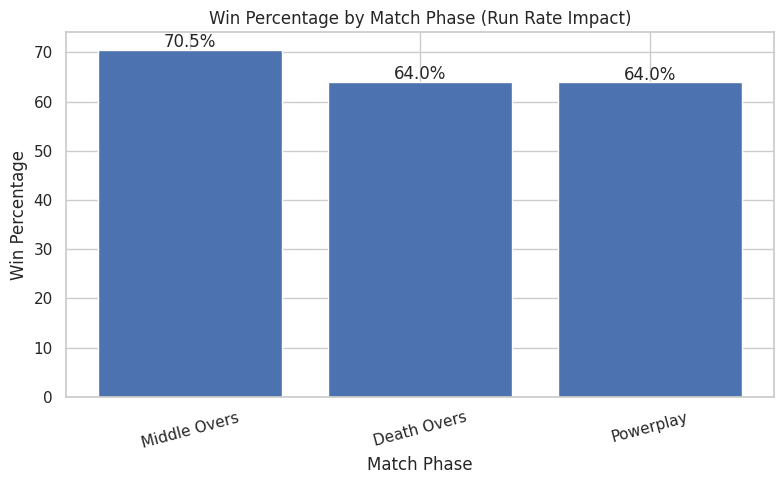

In [28]:
# create a new figure for phase run impact chart
plt.figure(figsize=(8, 5))

# create bar chart for win percentage by phase using run-rate-based impact
plt.bar(phase_impact['phase'], phase_impact['win_percentage'])

# set chart title
plt.title('Win Percentage by Match Phase (Run Rate Impact)')

# set x-axis label
plt.xlabel('Match Phase')

# set y-axis label
plt.ylabel('Win Percentage')

# rotate x-axis labels slightly for better readability
plt.xticks(rotation=15)

# add value labels on top of each bar
for i, value in enumerate(phase_impact['win_percentage']):
    plt.text(i, value + 0.5, f'{value:.1f}%', ha='center')

# adjust layout so labels do not overlap
plt.tight_layout()

# display the chart
plt.show()

In [29]:
# CHECK WICKETS IMPACT BY PHASE

# pivot wickets like we did for run rate
wicket_pivot = phase_summary.pivot_table(
    index=['matchId', 'phase'],
    columns='inning',
    values='wickets'
).reset_index()

# rename columns
wicket_pivot.columns = ['matchId', 'phase', 'team1_wickets', 'team2_wickets']

# identify which team lost fewer wickets (better performance)
wicket_pivot['wicket_winner'] = wicket_pivot.apply(
    lambda row: 1 if row['team1_wickets'] < row['team2_wickets']
    else (2 if row['team2_wickets'] < row['team1_wickets'] else 0),
    axis=1
)

# merge with match winner info
wicket_pivot = wicket_pivot.merge(
    phase_pivot[['matchId', 'phase', 'winning_inning']],
    on=['matchId', 'phase'],
    how='left'
)

# check if wicket advantage matches match winner
wicket_pivot['wicket_win_match_win'] = (
    wicket_pivot['wicket_winner'] == wicket_pivot['winning_inning']
).astype(int)

# calculate win %
wicket_impact = wicket_pivot.groupby('phase')['wicket_win_match_win'].mean().reset_index()
wicket_impact['win_percentage'] = wicket_impact['wicket_win_match_win'] * 100

wicket_impact

,phase,wicket_win_match_win,win_percentage
0,Death Overs,0.572864,57.286432
1,Middle Overs,0.554229,55.422886
2,Powerplay,0.534328,53.432836


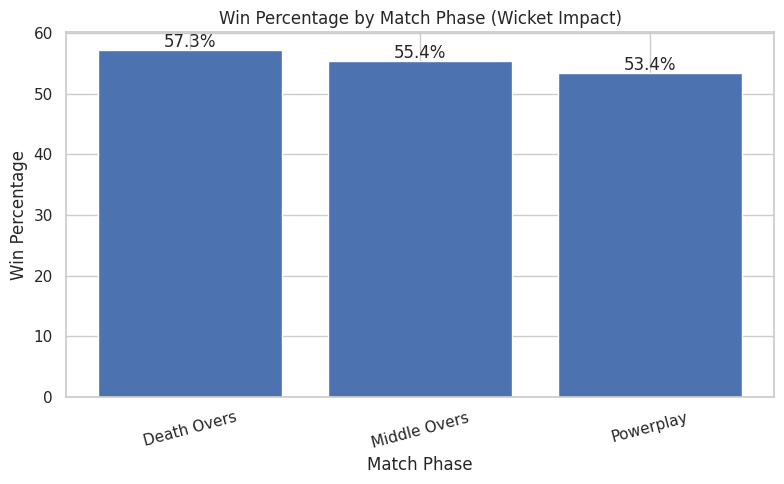

In [30]:
# create a new figure for wicket impact chart
plt.figure(figsize=(8, 5))

# create bar chart for win percentage by phase using wicket-based impact
plt.bar(wicket_impact['phase'], wicket_impact['win_percentage'])

# set chart title
plt.title('Win Percentage by Match Phase (Wicket Impact)')

# set x-axis label
plt.xlabel('Match Phase')

# set y-axis label
plt.ylabel('Win Percentage')

# rotate x-axis labels slightly for better readability
plt.xticks(rotation=15)

# add value labels on top of each bar
for i, value in enumerate(wicket_impact['win_percentage']):
    plt.text(i, value + 0.5, f'{value:.1f}%', ha='center')

# adjust layout so labels do not overlap
plt.tight_layout()

# display the chart
plt.show()

Analyzed how wicket-taking in different match phases influences winning outcomes by visualizing phase-wise win percentages.

The results emphasize the importance of death overs, where taking wickets under pressure plays a critical role in deciding matches.

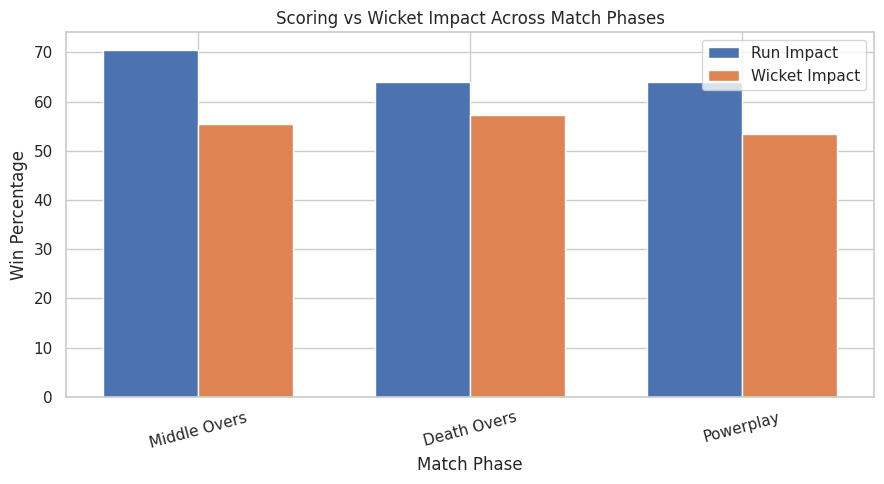

In [31]:
# merge run impact and wicket impact tables on phase
combined_phase_impact = phase_impact[['phase', 'win_percentage']].merge(
    wicket_impact[['phase', 'win_percentage']],
    on='phase',
    suffixes=('_run', '_wicket')
)

# create x-axis positions for grouped bars
x = range(len(combined_phase_impact))

# set bar width for grouped chart
bar_width = 0.35

# create a new figure for combined impact chart
plt.figure(figsize=(9, 5))

# plot run impact bars
plt.bar(
    [i - bar_width / 2 for i in x],
    combined_phase_impact['win_percentage_run'],
    width=bar_width,
    label='Run Impact'
)

# plot wicket impact bars
plt.bar(
    [i + bar_width / 2 for i in x],
    combined_phase_impact['win_percentage_wicket'],
    width=bar_width,
    label='Wicket Impact'
)

# set chart title
plt.title('Scoring vs Wicket Impact Across Match Phases')

# set x-axis label
plt.xlabel('Match Phase')

# set y-axis label
plt.ylabel('Win Percentage')

# set x-axis tick labels
plt.xticks(x, combined_phase_impact['phase'], rotation=15)

# show legend
plt.legend()

# adjust layout for clean display
plt.tight_layout()

# display the chart
plt.show()

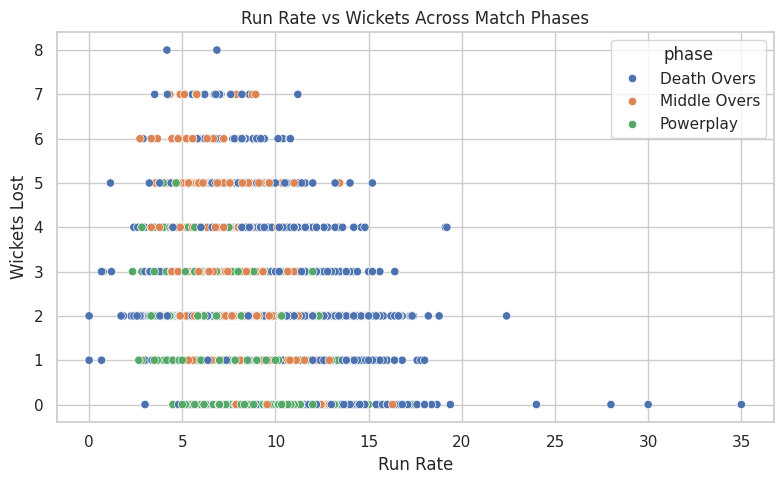

In [32]:
# RUN RATE vs WICKETS

# create scatter plot for run rate vs wickets by phase
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=phase_summary,
    x='run_rate',
    y='wickets',
    hue='phase'  # color by phase
)

# set title
plt.title('Run Rate vs Wickets Across Match Phases')

# set axis labels
plt.xlabel('Run Rate')
plt.ylabel('Wickets Lost')

# adjust layout
plt.tight_layout()

# show plot
plt.show()

Explored the balance between scoring aggression and risk by visualizing run rate against wickets lost across match phases.

This analysis highlights how different phases behave strategically with powerplay focusing on early momentum, middle overs on stability, and death overs on high-risk, high-reward acceleration.

**Match Winning Probability Based on Phase Dominance**

In [33]:
# STEP 1: COUNT PHASE WINS PER MATCH

# group by match and winning inning, count how many phases that inning won
phase_win_count = phase_pivot.groupby(
    ['matchId', 'winning_inning']
)['phase_win_match_win'].sum().reset_index()

# rename column for clarity
phase_win_count.columns = ['matchId', 'winning_inning', 'phases_won']

# check output
phase_win_count.head()

,matchId,winning_inning,phases_won
0,335982,1,3
1,335983,1,2
2,335984,2,3
3,335985,2,1
4,335986,2,1


In [34]:
# STEP 2: CATEGORIZE MATCHES BASED ON PHASE WINS

# categorize matches based on number of phases won
def categorize_phases(x):
    if x == 3:
        return "Won All 3 Phases"
    elif x == 2:
        return "Won 2 Phases"
    elif x == 1:
        return "Won 1 Phase"
    else:
        return "Won 0 Phases"

# apply categorization
phase_win_count['category'] = phase_win_count['phases_won'].apply(categorize_phases)

# check distribution
print(phase_win_count['category'].value_counts())

category
Won 2 Phases        628
Won 1 Phase         196
Won All 3 Phases    179
Won 0 Phases          2
Name: count, dtype: int64


In [35]:
# STEP 3: CALCULATE WIN PROBABILITY

# calculate percentage distribution of match outcomes by phase dominance
match_outcome = phase_win_count['category'].value_counts(normalize=True).reset_index()

# rename columns
match_outcome.columns = ['category', 'percentage']

# convert to percentage format
match_outcome['percentage'] = match_outcome['percentage'] * 100

# display result
match_outcome

,category,percentage
0,Won 2 Phases,62.487562
1,Won 1 Phase,19.502488
2,Won All 3 Phases,17.810945
3,Won 0 Phases,0.199005


Analyzed match-winning patterns by calculating the percentage distribution of outcomes based on phase dominance.

This approach quantifies how often teams win when they control different numbers of phases, revealing that consistent performance across multiple phases significantly increases the chances of victory.

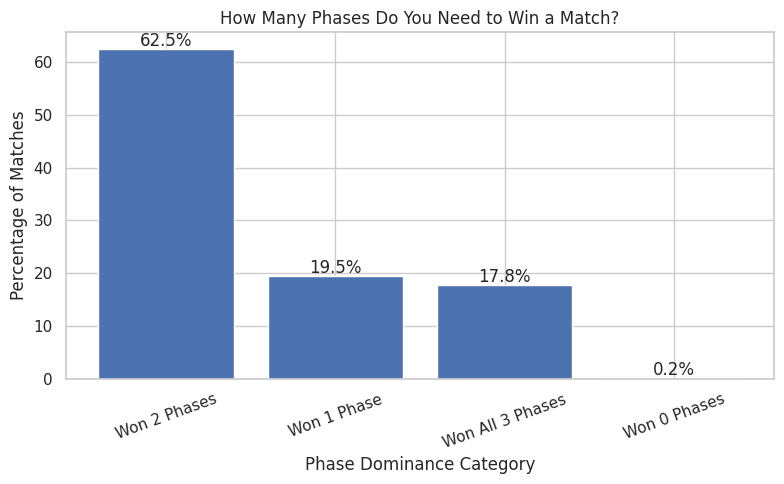

In [36]:
# create a new figure for match outcome category chart
plt.figure(figsize=(8, 5))

# create bar chart for match outcome categories
plt.bar(match_outcome['category'], match_outcome['percentage'])

# set chart title
plt.title('How Many Phases Do You Need to Win a Match?')

# set x-axis label
plt.xlabel('Phase Dominance Category')

# set y-axis label
plt.ylabel('Percentage of Matches')

# rotate x-axis labels for better readability
plt.xticks(rotation=20)

# add value labels on top of each bar
for i, value in enumerate(match_outcome['percentage']):
    plt.text(i, value + 0.5, f'{value:.1f}%', ha='center')

# adjust layout
plt.tight_layout()

# display the chart
plt.show()

Analyzed how phase dominance translates into match outcomes by visualizing the percentage of matches won based on the number of phases controlled.

The results highlight that winning at least two phases significantly increases the probability of winning, reinforcing the importance of consistent performance across different stages of the match.

**Impact Player Rule: Match Trends & Toss Decision Analysis**

In [37]:
# STEP 1: EXTRACT YEAR FROM SEASON

# create year column by extracting first 4 digits from season
full_df['year'] = full_df['season'].str[:4].astype(int)

# check sample
full_df[['season', 'year']].drop_duplicates().head()

,season,year
0,2007/08,2007
13489,2009,2009
26828,2009/10,2009
41067,2011,2011
58017,2012,2012


In [38]:
# STEP 2: CREATE IMPACT RULE PERIOD

# create period column based on year
full_df['impact_period'] = full_df['year'].apply(
    lambda x: 'Before Impact Rule' if x < 2023 else 'After Impact Rule'
)

# check distribution
print(full_df['impact_period'].value_counts())

impact_period
Before Impact Rule    221948
After Impact Rule      17745
Name: count, dtype: int64


In [39]:
# STEP 3: AVERAGE RUNS PER MATCH

# calculate total runs per match
match_runs = full_df.groupby(['matchId', 'impact_period'])['total_runs'].sum().reset_index()

# calculate average runs per match
avg_runs = match_runs.groupby('impact_period')['total_runs'].mean().reset_index()

# rename column
avg_runs.columns = ['impact_period', 'avg_runs_per_match']

# display result
avg_runs

,impact_period,avg_runs_per_match
0,After Impact Rule,350.178082
1,Before Impact Rule,311.940987


Analyzed overall scoring trends by calculating the average runs per match across different periods.

This comparison provides insight into how the introduction of the Impact Player rule has influenced batting aggression and whether it has led to more high-scoring matches.

In [40]:
# STEP 4: WICKETS PER MATCH

# calculate total wickets per match
match_wickets = full_df.groupby(['matchId', 'impact_period'])['wicket'].sum().reset_index()

# calculate average wickets per match
avg_wickets = match_wickets.groupby('impact_period')['wicket'].mean().reset_index()

# rename column
avg_wickets.columns = ['impact_period', 'avg_wickets_per_match']

# display result
avg_wickets

,impact_period,avg_wickets_per_match
0,After Impact Rule,12.452055
1,Before Impact Rule,11.714592


Analyzed bowling outcomes by calculating the average number of wickets per match across different periods.

This comparison helps understand how the introduction of the Impact Player rule has influenced match dynamics, particularly whether increased scoring has come with higher risk-taking and wicket loss.

In [41]:
# STEP 5: DEATH OVER RUN RATE

# filter only death overs
death_overs = full_df[full_df['phase'] == 'Death Overs']

# calculate run rate per match in death overs
death_rr = death_overs.groupby(['matchId', 'impact_period']).agg(
    runs=('total_runs', 'sum'),
    balls=('valid_ball', 'sum')
).reset_index()

# calculate run rate
death_rr['run_rate'] = (death_rr['runs'] / death_rr['balls']) * 6

# average by period
death_rr_summary = death_rr.groupby('impact_period')['run_rate'].mean().reset_index()

# display result
death_rr_summary

,impact_period,run_rate
0,After Impact Rule,10.425760
1,Before Impact Rule,9.646156


Analyzed death over scoring patterns by computing match-level run rates and comparing them across periods before and after the Impact Player rule.

This helps quantify changes in late-innings aggression, highlighting whether teams are scoring faster in the final overs in the modern IPL era.

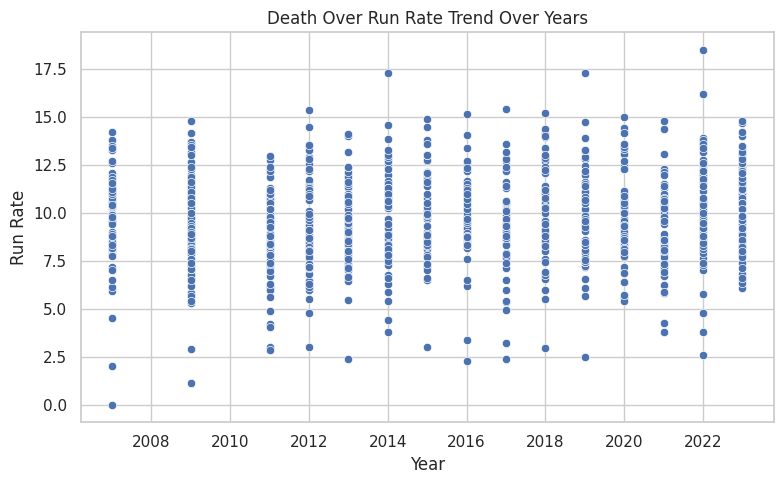

In [42]:
# create dataset for death overs
death_scatter = full_df[full_df['phase'] == 'Death Overs']

death_scatter = death_scatter.groupby(
    ['matchId', 'year']
).agg(
    runs=('total_runs', 'sum'),
    balls=('valid_ball', 'sum')
).reset_index()

# calculate run rate
death_scatter['run_rate'] = (death_scatter['runs'] / death_scatter['balls']) * 6

# plot
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=death_scatter,
    x='year',
    y='run_rate'
)

# title
plt.title('Death Over Run Rate Trend Over Years')

# labels
plt.xlabel('Year')
plt.ylabel('Run Rate')

# layout
plt.tight_layout()

plt.show()

Evaluated the evolution of scoring patterns in death overs by computing run rates across seasons and visualizing them using a scatter plot.

This analysis helps identify trends in late-innings aggression, revealing whether modern IPL matches are becoming more high-scoring, especially with tactical changes like the Impact Player rule.


In [43]:
# STEP 6: COUNT 200+ SCORES

# calculate total runs per inning
inning_runs = full_df.groupby(['matchId', 'inning', 'impact_period'])['total_runs'].sum().reset_index()

# flag 200+ innings
inning_runs['is_200_plus'] = (inning_runs['total_runs'] >= 200).astype(int)

# calculate percentage of 200+ scores
score_200 = inning_runs.groupby('impact_period')['is_200_plus'].mean().reset_index()

# convert to %
score_200['percentage'] = score_200['is_200_plus'] * 100

score_200

,impact_period,is_200_plus,percentage
0,After Impact Rule,0.253425,25.342466
1,Before Impact Rule,0.069742,6.974249


Analyzed the impact of the new rule on high-scoring innings by identifying how frequently teams score 200+ runs.

By aggregating runs at the innings level and comparing periods before and after the Impact Player rule, this metric highlights the shift in scoring behavior and the increasing attacking intent in modern IPL matches.

In [44]:
# Create a folder to store outputs (optional but clean)
import os

output_path = "ipl_outputs"
os.makedirs(output_path, exist_ok=True)


# 1. Phase Run Impact
phase_impact.to_csv(f"{output_path}/phase_run_impact.csv", index=False)

# 2. Phase Wicket Impact
wicket_impact.to_csv(f"{output_path}/phase_wicket_impact.csv", index=False)

# 3. Match Outcome (Phase Dominance)
match_outcome.to_csv(f"{output_path}/match_outcome_phase_analysis.csv", index=False)

# 4. Impact Rule - Avg Runs
avg_runs.to_csv(f"{output_path}/impact_avg_runs.csv", index=False)

# 5. Impact Rule - Avg Wickets
avg_wickets.to_csv(f"{output_path}/impact_avg_wickets.csv", index=False)

# 6. Impact Rule - Death Over Run Rate
death_rr_summary.to_csv(f"{output_path}/impact_death_rr.csv", index=False)

# 7. Impact Rule - 200+ Scores
score_200.to_csv(f"{output_path}/impact_200_scores.csv", index=False)

print("All files exported successfully!")

All files exported successfully!


Exported cleaned and transformed datasets into separate CSV files to support downstream visualization.

Each dataset captures a key analytical perspective phase-wise performance, match outcome patterns, and Impact Player rule effects enabling structured dashboard creation and clear communication of insights.